# Assignment 2 - Poject 7 Mixed Precision Training Strategy for VAE and VQ-VAE


## Description
Variational Autoencoders (VAE) and Vector Quantized Variational Autoencoders (VQ-VAE) are powerful generative models used in the field of deep learning for unsupervised learning tasks. This project aims to compare the performance of these models on three benchmark datasets: CIFAR-10, MNIST, and Fashion-MNIST. A key aspect of this comparison will be the use of normal and mixed precision training approaches, which have implications for training efficiency and model accuracy.

### Objectives

 - Implement VAE and VQ-VAE models in a deep learning framework
 - Train and evaluate these models on CIFAR-10, MNIST, and Fashion-MNIST datasets
 - Compare the performance of each model using normal and mixed precision training methods.
- Analyze the effects of precision training on the efficiency and accuracy of the models.

### notes on approach - A

- implimentation
    - VAE and VQ-VAE
- train both on each dataset
- comparison
    - mixed vs normal precision training
- analysis 
    - generation quality and reconstruction quality
    - training efficency
    - accuacay and preformance trade-offs
    

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os
import time
import pathlib as Path
import sys
import pandas as pd
from tqdm import tqdm

from torchvision import datasets, transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader

from dataclasses import dataclass
from typing import Tuple, Dict, Optional


### Config varables

In [7]:
DATA_DIR = "./data"
OUTPUT_DIR = "./outputs"

BATCH_SIZE = 128
NUM_WORKERS = 2
LEARNING_RATE = 1e-3
LATENT_DIM = 64
dev_EPOCHS = 5
prod_EPOCHS = 50
CAPACITY = 64
VARIATIONAL_BETA = 0.25

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
#Make sure GPU torch is instaled and available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
#Check if GPU is available and set device accordingly
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


### Data Functions

In [9]:

def get_datasets(data_dir="./data", dataset_name="mnist"):
    transform = transforms.Compose([transforms.ToTensor()])

    if dataset_name == "mnist":
        train_set = datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 1, 28

    elif dataset_name == "fashion-mnist":
        train_set = datasets.FashionMNIST(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.FashionMNIST(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 1, 28

    elif dataset_name == "cifar10":
        train_set = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
        in_channels, input_size = 3, 32

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    return train_set, test_set, in_channels, input_size

def get_dataloaders(data_dir="./data", dataset_name="mnist", batch_size=128, num_workers=2):
    train_set, test_set, in_channels, input_size = get_datasets(data_dir, dataset_name)

    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True
    )
    test_loader = DataLoader(
        test_set, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True
    )

    return train_loader, test_loader, in_channels, input_size

In [10]:
def show_batch(images, n=8, title="Batch"):
    images = images[:n].cpu()
    grid = vutils.make_grid(images, nrow=n, padding=2)
    plt.figure(figsize=(n * 1.5, 2))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray" if images.shape[1] == 1 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()

### Fetch data

In [11]:
mnist_train, mnist_test, mnist_in_channels, mnist_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
fashion_mnist_train, fashion_mnist_test, fashion_mnist_in_channels, fashion_mnist_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="fashion-mnist",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
cifar10_train, cifar10_test, cifar10_in_channels, cifar10_input_size = get_dataloaders(
    data_dir=DATA_DIR,
    dataset_name="cifar10",
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

torch.Size([128, 1, 28, 28]) torch.Size([128])


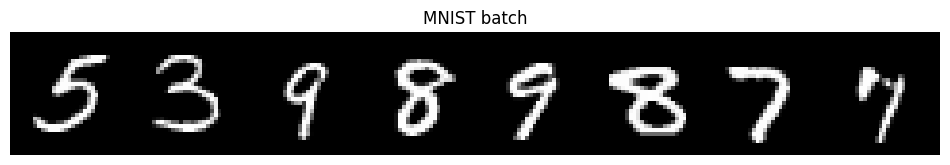

torch.Size([128, 1, 28, 28]) torch.Size([128])


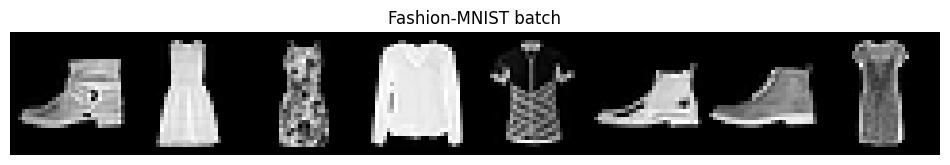

torch.Size([128, 3, 32, 32]) torch.Size([128])


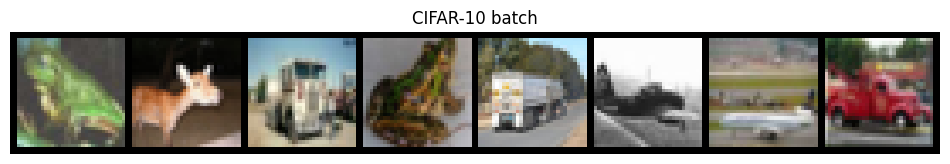

In [12]:
mnist_images, labels = next(iter(mnist_train))
fashion_mnist_images, labels1 = next(iter(fashion_mnist_train))
cifar10_images, labels2 = next(iter(cifar10_train))

print(mnist_images.shape, labels.shape)
show_batch(mnist_images, title="MNIST batch")
print(fashion_mnist_images.shape, labels1.shape)
show_batch(fashion_mnist_images, title="Fashion-MNIST batch")
print(cifar10_images.shape, labels2.shape)
show_batch(cifar10_images, title="CIFAR-10 batch")

## VQ-VAE section

Add complexity, by introducing up- down- and res- blocks that can be tuned 

#### VQ-VAE functions

In [22]:

@dataclass
class VQLossOutput:
    loss: torch.Tensor
    recon_loss: torch.Tensor
    vq_loss: torch.Tensor
    codebook_loss: torch.Tensor
    commitment_loss: torch.Tensor
    perplexity: torch.Tensor

class Encoder(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=128, latent_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_channels, latent_dim, kernel_size=3, stride=1, padding=1)
        )

    def forward(self, x):
        return self.net(x)
    
class Decoder(nn.Module):
    def __init__(self, latent_dim=256, hidden_channels=128, out_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_channels, hidden_channels, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_channels, out_channels, kernel_size=3, stride=1, padding=1)
        )

    def forward(self, z):
        return self.net(z)

    
class VectorQuantizer(nn.Module):
    def __init__(self, code_book_size=512, embedding_dim=256, commitment_cost=0.25):
        super().__init__()
        self.code_book_size = code_book_size
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.embedding=nn.Embedding(self.code_book_size, embedding_dim)
        self.embedding.weight.data.uniform_(-1/self.code_book_size, 1/self.code_book_size)

    def forward(self, z):
        z = z.permute(0, 2, 3, 1).contiguous() 
        z_shape = z.shape
        z_flattened = z.view(-1, self.embedding_dim)

        distances = ((z_flattened.unsqueeze(1) - self.embedding.weight.unsqueeze(0)).pow(2).mean(dim=2))
        encoding_indices = torch.argmin(distances, dim=1)
        
        quantized = self.embedding(encoding_indices)
        quantized = quantized.view(z_shape)

        e_latent_loss = F.mse_loss(quantized.detach(), z)
        q_latent_loss = F.mse_loss(quantized, z.detach())
        loss = q_latent_loss + self.commitment_cost * e_latent_loss

       
        quantized = z + (quantized - z).detach()
        quantized = quantized.permute(0, 3, 1, 2).contiguous()

        
        encoding_indices = encoding_indices.view(z_shape[0], z_shape[1], z_shape[2])

        return loss, quantized, encoding_indices


class VQVAE(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=128, latent_dim=256, code_book_size=512, commitment_cost=0.25):
        super().__init__()

        self.encoder = Encoder(in_channels=in_channels, hidden_channels=hidden_channels, latent_dim=latent_dim)
        self.vq = VectorQuantizer(code_book_size=code_book_size,embedding_dim=latent_dim,commitment_cost=commitment_cost)
        self.decoder = Decoder(latent_dim=latent_dim, hidden_channels=hidden_channels, out_channels=in_channels)

    def encode(self, x):
        z = self.encoder(x)
        vq_loss, quantized, encoding_indices = self.vq(z)
        return vq_loss, quantized, encoding_indices

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        vq_loss, quantized, encoding_indices = self.encode(x)
        recon = self.decode(quantized)
        return recon, vq_loss, quantized, encoding_indices
    



def evaluate_vqvae(model, dataloader, device, use_mixed_precision=False):
    model.eval()
    

    total_recon_loss = 0.0
    total_vq_loss = 0.0
    total_loss = 0.0

    autocast_enabled = use_mixed_precision and torch.cuda.is_available()
    autocast_device = 'cuda' if torch.cuda.is_available() else 'cpu'

    with torch.no_grad():
        for data in tqdm(dataloader, leave=False, desc="Testing"):
            image = data[0].to(device)

            with torch.amp.autocast(device_type=autocast_device, enabled=autocast_enabled):
                recon_data, vq_loss, quantized, encoding_indices = model(image)

                recon_loss = F.mse_loss(recon_data, image)
                loss = recon_loss + vq_loss

            total_recon_loss += recon_loss.item()
            total_vq_loss += vq_loss.item()
            total_loss += loss.item()

    num_batches = len(dataloader)

    return {
        "recon_loss": total_recon_loss / num_batches,
        "vq_loss": total_vq_loss / num_batches,
        "loss": total_loss / num_batches,
    }


def train_vqvae(model, train_loader, test_loader, device, epochs=5, learning_rate=1e-3,
                use_mixed_precision=False, scheduler_type="cosine", weight_decay=0.0):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    startTime = time.perf_counter()

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(use_mixed_precision and torch.cuda.is_available())
    )

    if scheduler_type == "cosine":
        lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs,
            eta_min=0
        )
    elif scheduler_type is None:
        lr_scheduler = None
    else:
        raise ValueError("scheduler_type must be 'cosine' or None")

    train_recon_loss_batch = []
    train_vq_loss_batch = []
    train_total_loss_batch = []

    train_recon_loss_epoch = []
    train_vq_loss_epoch = []
    train_total_loss_epoch = []

    test_recon_loss_epoch = []
    test_vq_loss_epoch = []
    test_total_loss_epoch = []

    autocast_enabled = use_mixed_precision and torch.cuda.is_available()
    autocast_device = "cuda" if torch.cuda.is_available() else "cpu"

    pbar = tqdm(range(epochs), leave=False, desc="Epoch")

    for epoch in pbar:
        model.train()

        epoch_recon_loss = 0.0
        epoch_vq_loss = 0.0
        epoch_total_loss = 0.0

        for data in tqdm(train_loader, leave=False, desc="Training"):
            image = data[0].to(device)

            optimizer.zero_grad()

            with torch.amp.autocast(device_type=autocast_device, enabled=autocast_enabled):
                recon_data, vq_loss, quantized, encoding_indices = model(image)
                recon_loss = F.mse_loss(recon_data, image)
                loss = recon_loss + vq_loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_recon_loss_batch.append(recon_loss.item())
            train_vq_loss_batch.append(vq_loss.item())
            train_total_loss_batch.append(loss.item())

            epoch_recon_loss += recon_loss.item()
            epoch_vq_loss += vq_loss.item()
            epoch_total_loss += loss.item()

        if lr_scheduler is not None:
            lr_scheduler.step()

        num_train_batches = len(train_loader)

        train_recon_avg = epoch_recon_loss / num_train_batches
        train_vq_avg = epoch_vq_loss / num_train_batches
        train_total_avg = epoch_total_loss / num_train_batches

        train_recon_loss_epoch.append(train_recon_avg)
        train_vq_loss_epoch.append(train_vq_avg)
        train_total_loss_epoch.append(train_total_avg)

        test_metrics = evaluate_vqvae(
            model=model,
            dataloader=test_loader,
            device=device,
            use_mixed_precision=use_mixed_precision,
        )

        test_recon_loss_epoch.append(test_metrics["recon_loss"])
        test_vq_loss_epoch.append(test_metrics["vq_loss"])
        test_total_loss_epoch.append(test_metrics["loss"])

        pbar.set_postfix_str(f"train={train_total_avg:.4f}, test={test_metrics['loss']:.4f}")

    endTime = time.perf_counter()
    TrainingTime = endTime - startTime

    return {
        "model": model,
        "optimizer": optimizer,
        "train_recon_loss_batch": train_recon_loss_batch,
        "train_vq_loss_batch": train_vq_loss_batch,
        "train_total_loss_batch": train_total_loss_batch,
        "train_recon_loss": train_recon_loss_epoch,
        "train_vq_loss": train_vq_loss_epoch,
        "train_total_loss": train_total_loss_epoch,
        "test_recon_loss": test_recon_loss_epoch,
        "test_vq_loss": test_vq_loss_epoch,
        "test_total_loss": test_total_loss_epoch,
        "Training_time": TrainingTime
    }
    




def show_vqvae_results(history, test_loader=None, device=None, images=None, num_images=8):
    model = history["model"]
    model.eval()

    # Learning curves
    plt.figure(figsize=(15, 8))

    plt.subplot(2, 2, 1)
    plt.plot(history["train_recon_loss_batch"], label="Train Recon (batch)")
    plt.plot(history["train_vq_loss_batch"], label="Train VQ (batch)")
    plt.plot(history["train_total_loss_batch"], label="Train Total (batch)")
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.title("Detailed Training Curves")
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(history["train_recon_loss"], label="Train Recon (epoch)")
    plt.plot(history["test_recon_loss"], label="Test Recon (epoch)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Reconstruction Loss")
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(history["train_vq_loss"], label="Train VQ (epoch)")
    plt.plot(history["test_vq_loss"], label="Test VQ (epoch)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("VQ Loss")
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(history["train_total_loss"], label="Train Total (epoch)")
    plt.plot(history["test_total_loss"], label="Test Total (epoch)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Total Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Summary metrics
    print("Final Metrics")
    print(f"Training Time [s]:  {history['Training_time']:.6f}")
    print(f"Train Recon Loss: {history['train_recon_loss'][-1]:.6f}")
    print(f"Train VQ Loss:    {history['train_vq_loss'][-1]:.6f}")
    print(f"Train Total Loss: {history['train_total_loss'][-1]:.6f}")
    print(f"Test Recon Loss:  {history['test_recon_loss'][-1]:.6f}")
    print(f"Test VQ Loss:     {history['test_vq_loss'][-1]:.6f}")
    print(f"Test Total Loss:  {history['test_total_loss'][-1]:.6f}")


    # Images for visual comparison
    if images is None:
        if test_loader is None or device is None:
            return
        images, _ = next(iter(test_loader))

    if device is None:
        raise ValueError("device must be provided when showing reconstructions")

    images = images[:num_images].to(device)

    with torch.no_grad():
        recon_data, vq_loss, quantized, encoding_indices = model(images)

    images = images.cpu()
    recon_data = recon_data.cpu()

    recon_mse = ((recon_data - images) ** 2).mean().item()
    print(f"\nFinal batch reconstruction MSE: {recon_mse:.6f}")
    print(f"Batch VQ loss: {vq_loss.item():.6f}")
    print(f"Quantized latent shape: {quantized.shape}")
    print(f"Encoding indices shape: {encoding_indices.shape}")

    fig, axes = plt.subplots(2, num_images, figsize=(2 * num_images, 4))

    for i in range(num_images):
        original = images[i]
        reconstructed = recon_data[i]

        if original.shape[0] == 1:
            axes[0, i].imshow(original.squeeze(0), cmap="gray")
            axes[1, i].imshow(reconstructed.squeeze(0), cmap="gray")
        else:
            axes[0, i].imshow(original.permute(1, 2, 0))
            axes[1, i].imshow(reconstructed.permute(1, 2, 0))

        axes[0, i].axis("off")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Recon", fontsize=12)

    plt.tight_layout()
    plt.show()




def show_vqvae_curves(history, vq_nepoch):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    train_start = 200 if len(history["train_recon_loss_batch"]) > 200 else 0
    x_train = np.linspace(0, vq_nepoch, len(history["train_recon_loss_batch"][train_start:]))
    plt.plot(x_train, history["train_recon_loss_batch"][train_start:], label="Train Recon")

    x_test = np.linspace(0, vq_nepoch, len(history["test_recon_loss"]))
    plt.plot(x_test, history["test_recon_loss"], label="Test Recon")

    plt.title("Reconstruction Loss")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    vq_start = 100 if len(history["train_vq_loss_batch"]) > 100 else 0
    x_vq = np.linspace(0, vq_nepoch, len(history["train_vq_loss_batch"][vq_start:]))
    plt.plot(x_vq, history["train_vq_loss_batch"][vq_start:], label="Train VQ")

    plt.title("VQ Loss")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()

#### VQ-VAE implimentation

In [14]:
# Additional variables
code_book_size = 64
hidden_channels = 10
vq_nepoch = dev_EPOCHS

In [18]:
vae_net = VQVAE(in_channels=mnist_in_channels, hidden_channels=hidden_channels, latent_dim=LATENT_DIM, code_book_size=code_book_size, commitment_cost=0.25).to(device)


history = train_vqvae(
    model=vae_net,
    train_loader=mnist_train,
    test_loader=mnist_test,
    device=device,
    epochs=vq_nepoch,
    use_mixed_precision=False,
)

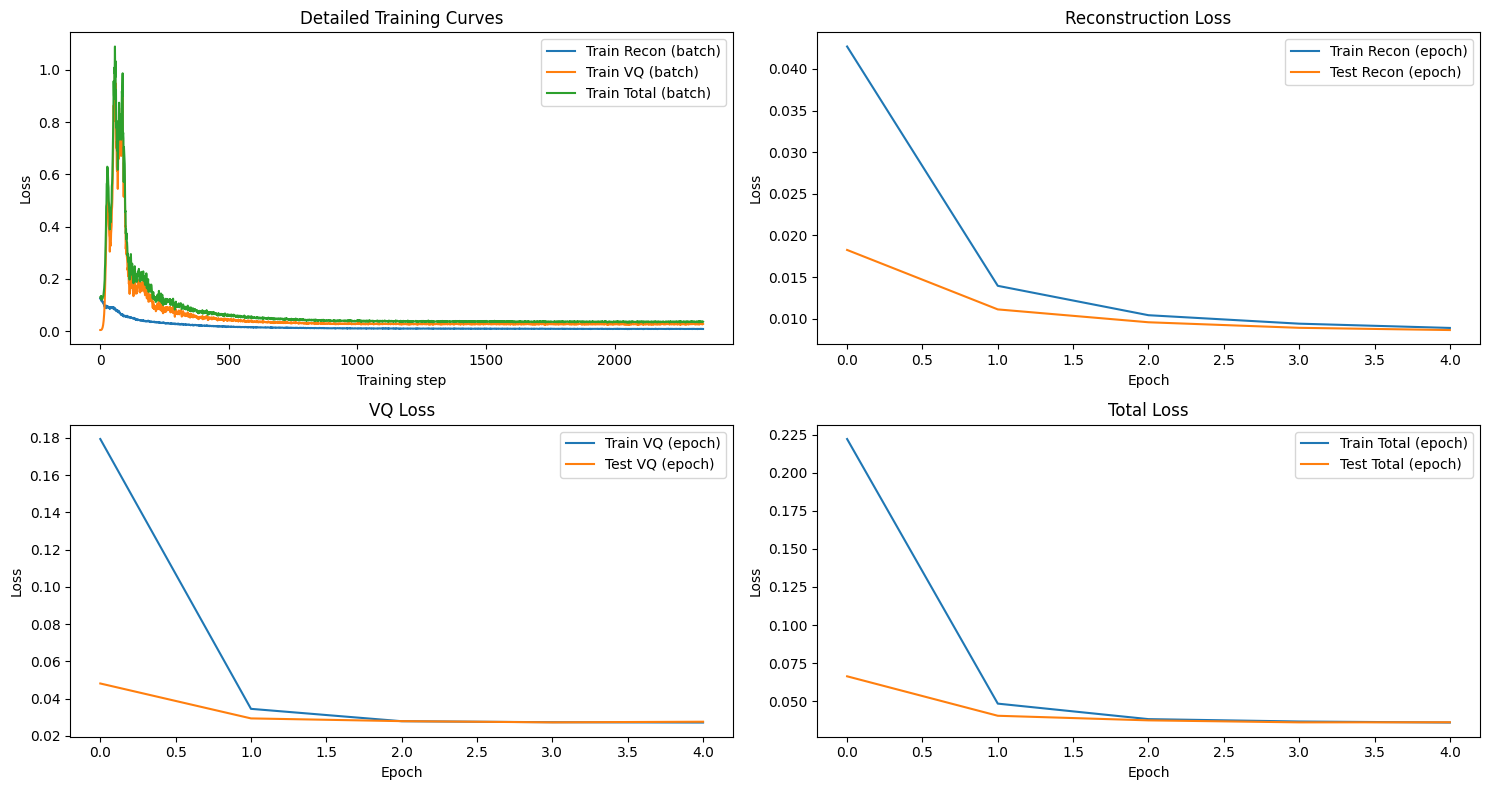

Final Metrics
Training Time [s]:  62.304335
Train Recon Loss: 0.008897
Train VQ Loss:    0.027086
Train Total Loss: 0.035982
Test Recon Loss:  0.008644
Test VQ Loss:     0.027530
Test Total Loss:  0.036174

Final batch reconstruction MSE: 0.006405
Batch VQ loss: 0.019969
Quantized latent shape: torch.Size([8, 64, 7, 7])
Encoding indices shape: torch.Size([8, 7, 7])


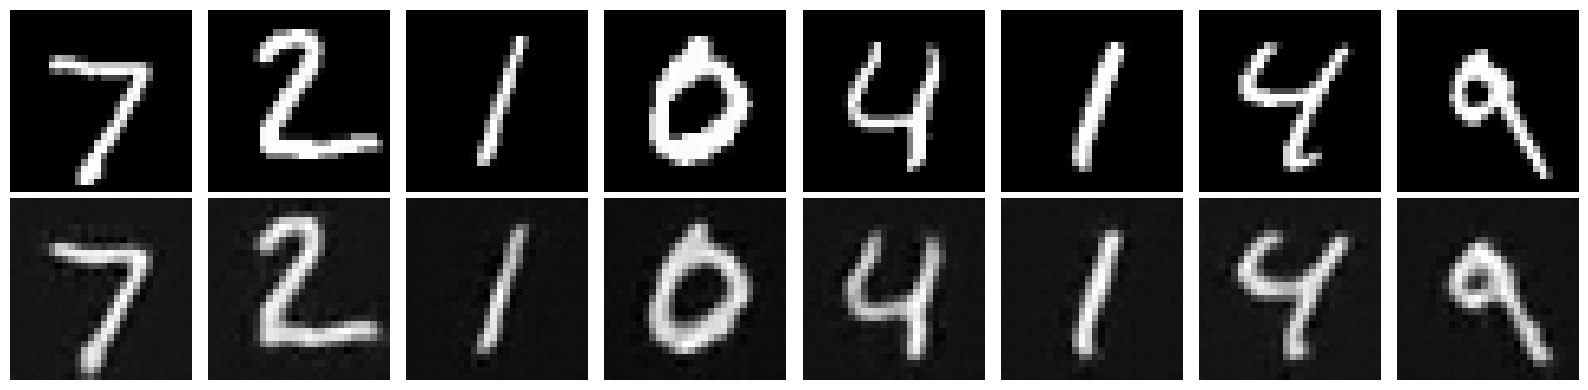

In [ ]:
show_vqvae_results(history, mnist_test, device, num_images=8)


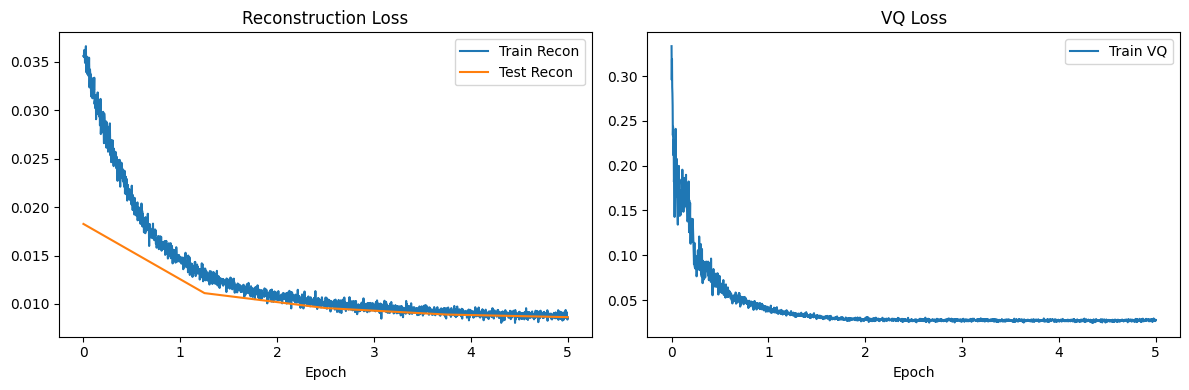

In [24]:
show_vqvae_curves(history, vq_nepoch)